# Clean data and process

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== User settings =====
base_dir = Path(r"D:\Arduino\Physic2 project\Data processing\Data Session use!!!!")   # change if needed
min_runtime_s = 29.0                                    # keep only runs >= this
exclude_transient_s_start = 3.0                         # remove first few seconds in averaging
exclude_transient_s_end = 2.0                           # remove last few seconds in averaging
use_absolute_thrust = True                              # compare thrust magnitude
SUPPLY_V = 11.1                                         # fixed supply voltage used for power and g/W

# Optional manual order for nicer plots
condition_order = ["Without dome", "With dome gina", "With dome Saipan", "With dome Saipan 1"]

condition_colors = {
    "Without dome": "blue",
    "With dome gina": "orange",
    "With dome Saipan": "green",
    "With dome Saipan 1": "red"
}


Use to extract command and parse

In [2]:
def parse_ts(line):
    m = re.match(r"\[(.*?)\]", line)
    return pd.to_datetime(m.group(1), errors="coerce") if m else pd.NaT


def parse_serial_log(path):
    rows = []
    with open(path, encoding="utf-8", errors="ignore") as f:
        for raw_line in f:
            line = raw_line.strip()
            ts = parse_ts(line)
            event = None
            value = np.nan

            if "[TX]" in line:
                if "CAL=" in line:
                    event = "CAL"
                    m = re.search(r"CAL=([0-9.]+)", line)
                    value = float(m.group(1)) if m else np.nan
                elif re.search(r"\[TX\]\s*TARE\b", line):
                    event = "TARE"
                elif re.search(r"\[TX\]\s*SPEED\s+(\d+)\b", line):
                    event = "SPEED"
                    m = re.search(r"\[TX\]\s*SPEED\s+(\d+)\b", line)
                    value = int(m.group(1)) if m else np.nan
                elif re.search(r"\[TX\]\s*ON\b", line):
                    event = "ON"
                elif re.search(r"\[TX\]\s*OFF\b", line):
                    event = "OFF"

            if "Motor disabled due to command timeout." in line:
                event = "TIMEOUT"

            rows.append({
                "ts": ts,
                "line": line,
                "event": event,
                "value": value,
            })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["ts", "line"], na_position="last").reset_index(drop=True)
    return df


def parse_plot_csv(path):
    df = pd.read_csv(path)
    df["pc_time"] = pd.to_datetime(df["pc_time"], errors="coerce")

    for col in ["ms", "time_s", "current_a", "thrust_g"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "thrust_g" in df.columns:
        df["thrust_abs_g"] = df["thrust_g"].abs()
    else:
        df["thrust_g"] = np.nan
        df["thrust_abs_g"] = np.nan

    df = df.dropna(subset=["pc_time"]).sort_values("pc_time").reset_index(drop=True)
    return df


def latest_cal_time(log_df):
    cal = log_df[log_df["event"] == "CAL"]
    return cal["ts"].max() if len(cal) else pd.NaT


def weighted_mean(values, weights):
    values = pd.to_numeric(pd.Series(values).reset_index(drop=True), errors="coerce")
    weights = pd.to_numeric(pd.Series(weights).reset_index(drop=True), errors="coerce")
    mask = values.notna() & weights.notna() & (weights > 0)
    if not mask.any():
        return np.nan
    return np.average(values[mask], weights=weights[mask])


In [3]:
def build_control_sessions(log_df, csv_end_ts, analysis_start_ts):
    """
    Build one control session per ON ... TIMEOUT / OFF / CSV_END window.
    The interest window is the FIRST SPEED command after ON until the end event.
    """
    events = (
        log_df[
            (log_df["ts"] >= analysis_start_ts)
            & (log_df["event"].isin(["ON", "SPEED", "TIMEOUT", "OFF"]))
        ]
        .sort_values("ts")
        .reset_index(drop=True)
    )

    segments = []
    control_session_id = 0

    on_indices = events.index[events["event"] == "ON"].tolist()

    for pos, on_idx in enumerate(on_indices):
        on_row = events.loc[on_idx]

        # Limit search to the current ON window so later ON events do not create overlaps.
        next_on_idx = on_indices[pos + 1] if pos + 1 < len(on_indices) else None
        stop_idx = (next_on_idx - 1) if next_on_idx is not None else events.index.max()
        after_on = events.loc[on_idx + 1 : stop_idx].copy()

        # Prefer TIMEOUT as the end marker.
        timeout_rows = after_on[after_on["event"] == "TIMEOUT"]
        off_rows = after_on[after_on["event"] == "OFF"]

        if len(timeout_rows):
            end_ts = timeout_rows["ts"].iloc[0]
            end_event = "TIMEOUT"
        elif len(off_rows):
            end_ts = off_rows["ts"].iloc[0]
            end_event = "OFF"
        else:
            end_ts = csv_end_ts
            end_event = "CSV_END"

        speed_rows = after_on[
            (after_on["event"] == "SPEED") &
            (after_on["ts"] < end_ts)
        ].copy()

        # Skip ON windows that never received a SPEED command.
        if speed_rows.empty:
            continue

        first_speed_row = speed_rows.iloc[0]
        start_ts = first_speed_row["ts"]
        speed_pct = int(first_speed_row["value"]) if pd.notna(first_speed_row["value"]) else np.nan
        runtime_s = (end_ts - start_ts).total_seconds() if pd.notna(end_ts) and pd.notna(start_ts) else np.nan

        if pd.notna(runtime_s) and runtime_s < 0:
            continue

        control_session_id += 1
        segments.append({
            "control_session_id": control_session_id,
            "start_event": "SPEED",
            "end_event": end_event,
            "on_ts": on_row["ts"],
            "start_ts": start_ts,
            "end_ts": end_ts,
            "runtime_s": runtime_s,
            "speed_pct": speed_pct,
            "all_speed_commands_after_on": ", ".join(
                map(str, speed_rows["value"].dropna().astype(int).tolist())
            ),
            "speed_command_count_after_on": int(len(speed_rows)),
            "qualifies": bool(pd.notna(runtime_s) and runtime_s >= min_runtime_s),
        })

    return pd.DataFrame(segments)


In [4]:
def summarize_segment(segment_df, speed_pct, runtime_s, run_id):
    segment_df = segment_df.sort_values("pc_time").copy()
    rel_s = (segment_df["pc_time"] - segment_df["pc_time"].iloc[0]).dt.total_seconds()

    stable = segment_df[rel_s >= exclude_transient_s_start].copy()
    if not stable.empty:
        until_end = (segment_df["pc_time"].iloc[-1] - stable["pc_time"]).dt.total_seconds()
        stable = stable[until_end >= exclude_transient_s_end].copy()

    used = stable if len(stable) >= 10 else segment_df.copy()

    thrust_col = "thrust_abs_g" if use_absolute_thrust else "thrust_g"

    current = pd.to_numeric(used["current_a"], errors="coerce").dropna()
    thrust = pd.to_numeric(used[thrust_col], errors="coerce").dropna()

    power = pd.to_numeric(used["current_a"], errors="coerce") * SUPPLY_V
    power = power.dropna()

    eff_g_per_a = (
        pd.to_numeric(used[thrust_col], errors="coerce")
        / pd.to_numeric(used["current_a"], errors="coerce").replace(0, np.nan)
    ).dropna()

    eff_g_per_w = (
        pd.to_numeric(used[thrust_col], errors="coerce")
        / (pd.to_numeric(used["current_a"], errors="coerce") * SUPPLY_V).replace(0, np.nan)
    ).dropna()

    current_mean = current.mean() if len(current) else np.nan
    thrust_mean = thrust.mean() if len(thrust) else np.nan
    power_mean = power.mean() if len(power) else np.nan

    current_sd = current.std(ddof=1) if len(current) >= 2 else np.nan
    thrust_sd = thrust.std(ddof=1) if len(thrust) >= 2 else np.nan
    power_sd = power.std(ddof=1) if len(power) >= 2 else np.nan
    eff_g_per_a_sd = eff_g_per_a.std(ddof=1) if len(eff_g_per_a) >= 2 else np.nan
    eff_g_per_w_sd = eff_g_per_w.std(ddof=1) if len(eff_g_per_w) >= 2 else np.nan

    return {
        "run_id": int(run_id),
        "speed_pct": int(speed_pct) if pd.notna(speed_pct) else np.nan,
        "runtime_s": float(runtime_s) if pd.notna(runtime_s) else np.nan,
        "samples_total": int(len(segment_df)),
        "samples_used": int(len(used)),
        "current_mean_A": current_mean,
        "current_sd_A": current_sd,
        "current_std_A": current_sd,  # backward-compatible alias
        "current_min_A": current.min() if len(current) else np.nan,
        "current_max_A": current.max() if len(current) else np.nan,
        "thrust_mean_g": thrust_mean,
        "thrust_sd_g": thrust_sd,
        "thrust_std_g": thrust_sd,  # backward-compatible alias
        "thrust_peak_g": thrust.max() if len(thrust) else np.nan,
        "power_mean_W": power_mean,
        "power_sd_W": power_sd,
        "efficiency_g_per_A": (
            thrust_mean / current_mean
            if pd.notna(thrust_mean) and pd.notna(current_mean) and current_mean != 0
            else np.nan
        ),
        "efficiency_sd_g_per_A": eff_g_per_a_sd,
        "efficiency_g_per_W": (
            thrust_mean / power_mean
            if pd.notna(thrust_mean) and pd.notna(power_mean) and power_mean != 0
            else np.nan
        ),
        "efficiency_sd_g_per_W": eff_g_per_w_sd,
    }


In [7]:
def analyze_dataset(base_dir):
    base_dir = Path(base_dir)
    if not base_dir.exists():
        raise FileNotFoundError(f"base_dir not found: {base_dir}")

    overall_rows = []
    all_control_session_tables = []
    speed_tables = []
    raw_interest = {}

    def pooled_sd_from_series(series):
        s = pd.to_numeric(series, errors="coerce").dropna()
        return s.std(ddof=1) if len(s) >= 2 else np.nan

    def sem_from_series(series):
        s = pd.to_numeric(series, errors="coerce").dropna()
        return (s.std(ddof=1) / np.sqrt(len(s))) if len(s) >= 2 else np.nan

    def pooled_sd_from_groups(sd_series, n_series):
        sd = pd.to_numeric(sd_series, errors="coerce")
        n = pd.to_numeric(n_series, errors="coerce")
        valid = sd.notna() & n.notna() & (n >= 2)
        if not valid.any():
            return np.nan
        sd = sd[valid]
        n = n[valid]
        denom = (n - 1).sum()
        if denom <= 0:
            return np.nan
        return np.sqrt((((n - 1) * (sd ** 2)).sum()) / denom)

    def sem_from_groups(sd_series, n_series):
        psd = pooled_sd_from_groups(sd_series, n_series)
        n = pd.to_numeric(n_series, errors="coerce")
        total_n = n[n.notna() & (n > 0)].sum()
        return psd / np.sqrt(total_n) if pd.notna(psd) and total_n > 0 else np.nan

    folders = [p for p in base_dir.iterdir() if p.is_dir()]
    folders = sorted(folders, key=lambda p: condition_order.index(p.name) if p.name in condition_order else 999)

    for folder in folders:
        condition = folder.name
        log_path = folder / "serial_log.txt"
        csv_path = folder / "plot_data.csv"
        if not log_path.exists() or not csv_path.exists():
            continue

        log_df = parse_serial_log(log_path)
        data_df = parse_plot_csv(csv_path)
        if data_df.empty:
            continue

        cal_ts = latest_cal_time(log_df)
        analysis_start_ts = cal_ts if pd.notna(cal_ts) else data_df["pc_time"].min()
        segs = build_control_sessions(
            log_df=log_df,
            csv_end_ts=data_df["pc_time"].max(),
            analysis_start_ts=analysis_start_ts,
        )

        frames = []
        session_rows = []

        if not segs.empty:
            segs = segs.copy()
            if "condition" not in segs.columns:
                segs.insert(0, "condition", condition)

        for i, seg in segs.reset_index(drop=True).iterrows():
            sub = data_df[
                (data_df["pc_time"] >= seg["start_ts"]) &
                (data_df["pc_time"] < seg["end_ts"])
            ].copy()

            if sub.empty:
                continue

            sub = sub.sort_values("pc_time").copy()
            thrust_col = "thrust_abs_g" if use_absolute_thrust else "thrust_g"

            sub["condition"] = condition
            sub["control_session_id"] = int(seg["control_session_id"])
            sub["speed_pct"] = seg["speed_pct"]
            sub["qualifies"] = bool(seg["qualifies"])
            sub["segment_start_ts"] = seg["start_ts"]
            sub["segment_end_ts"] = seg["end_ts"]
            sub["on_ts"] = seg["on_ts"]
            sub["runtime_s"] = seg["runtime_s"]
            sub["elapsed_from_segment_start_s"] = (sub["pc_time"] - seg["start_ts"]).dt.total_seconds()
            sub["elapsed_from_analysis_start_s"] = (sub["pc_time"] - analysis_start_ts).dt.total_seconds()
            sub["power_W"] = pd.to_numeric(sub["current_a"], errors="coerce") * SUPPLY_V
            sub["efficiency_g_per_W"] = pd.to_numeric(sub[thrust_col], errors="coerce") / sub["power_W"].replace(0, np.nan)
            frames.append(sub)

            row = summarize_segment(
                segment_df=sub,
                speed_pct=seg["speed_pct"],
                runtime_s=seg["runtime_s"],
                run_id=i + 1,
            )
            row.update({
                "condition": condition,
                "control_session_id": int(seg["control_session_id"]),
                "qualifies": bool(seg["qualifies"]),
                "on_ts": seg["on_ts"],
                "segment_start_ts": seg["start_ts"],
                "segment_end_ts": seg["end_ts"],
                "start_event": seg.get("start_event", "SPEED"),
                "end_event": seg.get("end_event", np.nan),
                "all_speed_commands_after_on": seg.get("all_speed_commands_after_on", ""),
                "speed_command_count_after_on": seg.get("speed_command_count_after_on", np.nan),
            })
            session_rows.append(row)

        sessions_df = pd.DataFrame(session_rows)
        if not sessions_df.empty:
            sessions_df = sessions_df.sort_values(["condition", "control_session_id"]).reset_index(drop=True)
        all_control_session_tables.append(sessions_df)

        interest_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
        if not interest_df.empty:
            interest_df = interest_df.sort_values(["condition", "control_session_id", "pc_time"]).reset_index(drop=True)
        raw_interest[condition] = interest_df

        thrust_col = "thrust_abs_g" if use_absolute_thrust else "thrust_g"

        if not interest_df.empty:
            m_curr = interest_df["current_a"].mean()
            m_thrus = interest_df[thrust_col].mean()
            m_power = (pd.to_numeric(interest_df["current_a"], errors="coerce") * SUPPLY_V).mean()

            sd_curr = pooled_sd_from_series(interest_df["current_a"])
            sd_thrus = pooled_sd_from_series(interest_df[thrust_col])
            sd_power = pooled_sd_from_series(pd.to_numeric(interest_df["current_a"], errors="coerce") * SUPPLY_V)

            sem_curr = sem_from_series(interest_df["current_a"])
            sem_thrus = sem_from_series(interest_df[thrust_col])
            sem_power = sem_from_series(pd.to_numeric(interest_df["current_a"], errors="coerce") * SUPPLY_V)
        else:
            m_curr = m_thrus = m_power = np.nan
            sd_curr = sd_thrus = sd_power = np.nan
            sem_curr = sem_thrus = sem_power = np.nan

        if not sessions_df.empty and "speed_pct" in sessions_df.columns:
            source_df = sessions_df.dropna(subset=["speed_pct"]).copy()
            agg_rows = []

            current_sd_col = "current_sd_A" if "current_sd_A" in source_df.columns else "current_std_A"
            thrust_sd_col = "thrust_sd_g" if "thrust_sd_g" in source_df.columns else "thrust_std_g"

            for speed, g in source_df.groupby("speed_pct"):
                raw_g = interest_df[interest_df["speed_pct"] == speed] if not interest_df.empty else pd.DataFrame()
                w = g["samples_used"].fillna(0).to_numpy()

                if not raw_g.empty:
                    c_sd = pooled_sd_from_series(raw_g["current_a"])
                    t_sd = pooled_sd_from_series(raw_g[thrust_col])
                    c_sem = sem_from_series(raw_g["current_a"])
                    t_sem = sem_from_series(raw_g[thrust_col])

                    raw_eff_g_per_a = raw_g[thrust_col] / raw_g["current_a"].replace(0, np.nan)
                    e_sd = pooled_sd_from_series(raw_eff_g_per_a)
                    e_sem = sem_from_series(raw_eff_g_per_a)

                    raw_power = pd.to_numeric(raw_g["current_a"], errors="coerce") * SUPPLY_V
                    p_sd = pooled_sd_from_series(raw_power)
                    p_sem = sem_from_series(raw_power)

                    raw_eff_g_per_w = raw_g[thrust_col] / raw_power.replace(0, np.nan)
                    gpw_sd = pooled_sd_from_series(raw_eff_g_per_w)
                    gpw_sem = sem_from_series(raw_eff_g_per_w)
                else:
                    c_sd = pooled_sd_from_groups(g[current_sd_col], g["samples_used"])
                    c_sem = sem_from_groups(g[current_sd_col], g["samples_used"])
                    t_sd = pooled_sd_from_groups(g[thrust_sd_col], g["samples_used"])
                    t_sem = sem_from_groups(g[thrust_sd_col], g["samples_used"])

                    if "efficiency_sd_g_per_A" in g.columns:
                        e_sd = pooled_sd_from_groups(g["efficiency_sd_g_per_A"], g["samples_used"])
                        e_sem = sem_from_groups(g["efficiency_sd_g_per_A"], g["samples_used"])
                    else:
                        e_sd = np.nan
                        e_sem = np.nan

                    if "power_sd_W" in g.columns:
                        p_sd = pooled_sd_from_groups(g["power_sd_W"], g["samples_used"])
                        p_sem = sem_from_groups(g["power_sd_W"], g["samples_used"])
                    else:
                        p_sd = np.nan
                        p_sem = np.nan

                    if "efficiency_sd_g_per_W" in g.columns:
                        gpw_sd = pooled_sd_from_groups(g["efficiency_sd_g_per_W"], g["samples_used"])
                        gpw_sem = sem_from_groups(g["efficiency_sd_g_per_W"], g["samples_used"])
                    else:
                        gpw_sd = np.nan
                        gpw_sem = np.nan

                agg_rows.append({
                    "condition": condition,
                    "speed_pct": int(speed),
                    "samples_used_total": int(g["samples_used"].sum()),
                    "current_mean_A_weighted": weighted_mean(g["current_mean_A"], w),
                    "current_sd_A": c_sd,
                    "current_uncertainty_A": c_sem,
                    "thrust_mean_g_weighted": weighted_mean(g["thrust_mean_g"], w),
                    "thrust_sd_g": t_sd,
                    "thrust_uncertainty_g": t_sem,
                    "power_mean_W_weighted": weighted_mean(g["power_mean_W"], w),
                    "power_sd_W": p_sd,
                    "power_uncertainty_W": p_sem,
                    "efficiency_g_per_A_weighted": weighted_mean(g["efficiency_g_per_A"], w),
                    "efficiency_sd_g_per_A": e_sd,
                    "efficiency_uncertainty_g_per_A": e_sem,
                    "efficiency_g_per_W_weighted": weighted_mean(g["efficiency_g_per_W"], w),
                    "efficiency_sd_g_per_W": gpw_sd,
                    "efficiency_uncertainty_g_per_W": gpw_sem,
                    "thrust_peak_g_max": g["thrust_peak_g"].max(),
                })

            speed_tables.append(pd.DataFrame(agg_rows))

        overall_rows.append({
            "condition": condition,
            "qualified_control_sessions": int(segs["qualifies"].sum()) if not segs.empty else 0,
            "rows_analyzed": int(len(interest_df)),
            "overall_mean_current_A": m_curr,
            "overall_sd_current_A": sd_curr,
            "overall_current_uncertainty_A": sem_curr,
            "overall_mean_thrust_g": m_thrus,
            "overall_sd_thrust_g": sd_thrus,
            "overall_thrust_uncertainty_g": sem_thrus,
            "overall_mean_power_W": m_power,
            "overall_sd_power_W": sd_power,
            "overall_power_uncertainty_W": sem_power,
            "overall_peak_thrust_g": interest_df[thrust_col].max() if not interest_df.empty else np.nan,
            "overall_efficiency_g_per_A": (
                m_thrus / m_curr
                if pd.notna(m_thrus) and pd.notna(m_curr) and m_curr != 0
                else np.nan
            ),
            "overall_efficiency_g_per_W": (
                m_thrus / m_power
                if pd.notna(m_thrus) and pd.notna(m_power) and m_power != 0
                else np.nan
            ),
        })

    overall_df = pd.DataFrame(overall_rows)
    control_sessions_df = pd.concat(all_control_session_tables, ignore_index=True) if all_control_session_tables else pd.DataFrame()
    per_speed_df = pd.concat(speed_tables, ignore_index=True) if speed_tables else pd.DataFrame()
    return overall_df, control_sessions_df, per_speed_df, raw_interest


In [12]:
def fmt_pm(mean_val, unc_val, decimals=3, unit=""):
    if pd.isna(mean_val) and pd.isna(unc_val):
        return ""
    if pd.isna(mean_val):
        return f"± {unc_val:.{decimals}f}{unit}"
    if pd.isna(unc_val):
        return f"{mean_val:.{decimals}f}{unit}"
    return f"{mean_val:.{decimals}f} ± {unc_val:.{decimals}f}{unit}"


def add_display_columns(overall_df, per_speed_df):
    overall_disp = overall_df.copy()
    per_speed_disp = per_speed_df.copy()

    # --- Overall Table Display ---
    if not overall_disp.empty:
        overall_disp["current_A_display"] = overall_disp.apply(
            lambda r: fmt_pm(r["overall_mean_current_A"], r["overall_current_uncertainty_A"], 3, " A"), axis=1
        )
        overall_disp["current_A_sd"] = overall_disp.apply(
            lambda r: f"SD: {r['overall_sd_current_A']:.3f}" if pd.notna(r["overall_sd_current_A"]) else "", axis=1
        )

        overall_disp["thrust_g_display"] = overall_disp.apply(
            lambda r: fmt_pm(r["overall_mean_thrust_g"], r["overall_thrust_uncertainty_g"], 2, " g"), axis=1
        )
        overall_disp["thrust_g_sd"] = overall_disp.apply(
            lambda r: f"SD: {r['overall_sd_thrust_g']:.2f}" if pd.notna(r["overall_sd_thrust_g"]) else "", axis=1
        )

        overall_disp["power_W_display"] = overall_disp.apply(
            lambda r: fmt_pm(r["overall_mean_power_W"], r["overall_power_uncertainty_W"], 3, " W"), axis=1
        )
        overall_disp["power_W_sd"] = overall_disp.apply(
            lambda r: f"SD: {r['overall_sd_power_W']:.3f}" if pd.notna(r["overall_sd_power_W"]) else "", axis=1
        )

        overall_disp["efficiency_g_per_A_display"] = overall_disp.apply(
            lambda r: fmt_pm(r["overall_efficiency_g_per_A"], np.nan, 2, " g/A"), axis=1
        )
        overall_disp["efficiency_g_per_W_display"] = overall_disp.apply(
            lambda r: fmt_pm(r["overall_efficiency_g_per_W"], np.nan, 2, " g/W"), axis=1
        )

    # --- Per-Speed Table Display ---
    if not per_speed_disp.empty:
        per_speed_disp["current_A_display"] = per_speed_disp.apply(
            lambda r: fmt_pm(r["current_mean_A_weighted"], r["current_uncertainty_A"], 3, " A"), axis=1
        )
        per_speed_disp["current_A_sd"] = per_speed_disp.apply(
            lambda r: f"{r['current_sd_A']:.3f}" if pd.notna(r["current_sd_A"]) else "", axis=1
        )

        per_speed_disp["thrust_g_display"] = per_speed_disp.apply(
            lambda r: fmt_pm(r["thrust_mean_g_weighted"], r["thrust_uncertainty_g"], 2, " g"), axis=1
        )
        per_speed_disp["thrust_g_sd"] = per_speed_disp.apply(
            lambda r: f"{r['thrust_sd_g']:.2f}" if pd.notna(r["thrust_sd_g"]) else "", axis=1
        )

        per_speed_disp["power_W_display"] = per_speed_disp.apply(
            lambda r: fmt_pm(r["power_mean_W_weighted"], r["power_uncertainty_W"], 3, " W"), axis=1
        )
        per_speed_disp["power_W_sd"] = per_speed_disp.apply(
            lambda r: f"{r['power_sd_W']:.3f}" if pd.notna(r["power_sd_W"]) else "", axis=1
        )

        per_speed_disp["efficiency_g_per_A_display"] = per_speed_disp.apply(
            lambda r: fmt_pm(r["efficiency_g_per_A_weighted"], r["efficiency_uncertainty_g_per_A"], 2, " g/A"), axis=1
        )
        per_speed_disp["efficiency_g_per_W_display"] = per_speed_disp.apply(
            lambda r: fmt_pm(r["efficiency_g_per_W_weighted"], r["efficiency_uncertainty_g_per_W"], 2, " g/W"), axis=1
        )

    return overall_disp, per_speed_disp


In [13]:
overall_df, all_control_sessions_df, per_speed_df, raw_interest = analyze_dataset(base_dir)

In [14]:
overall_disp, per_speed_disp = add_display_columns(overall_df, per_speed_df)

In [15]:
overall_disp_view = overall_disp[[
    "condition",
    "rows_analyzed",
    "current_A_display",
    "current_A_sd",
    "thrust_g_display",
    "thrust_g_sd",
    "power_W_display",
    "power_W_sd",
    "overall_peak_thrust_g",
    "efficiency_g_per_A_display",
    "efficiency_g_per_W_display",
]]

per_speed_disp_view = per_speed_disp[[
    "condition",
    "speed_pct",
    "samples_used_total",
    "current_A_display",
    "current_A_sd",
    "thrust_g_display",
    "thrust_g_sd",
    "power_W_display",
    "power_W_sd",
    "efficiency_g_per_A_display",
    "efficiency_g_per_W_display",
    "thrust_peak_g_max",
]]


In [16]:
display(overall_disp_view)
display(per_speed_disp_view)

,condition,rows_analyzed,current_A_display,current_A_sd,thrust_g_display,thrust_g_sd,overall_peak_thrust_g,efficiency_g_per_A_display
0,Without dome,1508,3.313 ± 0.053 A,SD: 2.076,149.41 ± 5.63 g,SD: 114.88,363.43,45.11 g/A
1,With dome gina,1514,3.160 ± 0.052 A,SD: 2.038,110.48 ± 3.99 g,SD: 81.40,271.15,34.96 g/A
2,With dome Saipan,1513,3.205 ± 0.053 A,SD: 2.051,74.26 ± 2.96 g,SD: 60.66,188.89,23.17 g/A
3,With dome Saipan 1,1510,3.101 ± 0.048 A,SD: 1.862,87.64 ± 3.44 g,SD: 70.17,213.94,28.26 g/A


,condition,speed_pct,samples_used_total,current_A_display,current_A_sd,thrust_g_display,thrust_g_sd,efficiency_g_per_A_display,thrust_peak_g_max
0,Without dome,20,213,0.916 ± 0.001 A,0.018,11.46 ± 0.25 g,2.09,12.51 ± 0.27 g/A,13.14
1,Without dome,30,213,1.475 ± 0.004 A,0.060,48.02 ± 1.01 g,8.48,32.56 ± 0.68 g/A,53.00
2,Without dome,40,212,2.320 ± 0.009 A,0.139,105.16 ± 2.18 g,18.14,45.34 ± 0.94 g/A,114.19
3,Without dome,50,212,3.556 ± 0.033 A,0.531,171.94 ± 4.03 g,33.45,48.36 ± 1.03 g/A,182.59
4,Without dome,60,213,4.878 ± 0.024 A,0.383,249.37 ± 4.89 g,40.59,51.13 ± 0.94 g/A,277.22
5,Without dome,70,212,6.921 ± 0.040 A,0.634,336.23 ± 6.78 g,56.75,48.58 ± 0.92 g/A,361.67
0,With dome gina,20,212,0.871 ± 0.001 A,0.017,9.73 ± 0.30 g,2.54,11.17 ± 0.35 g/A,15.31
1,With dome gina,30,212,1.401 ± 0.006 A,0.099,44.38 ± 1.16 g,9.64,31.68 ± 0.83 g/A,57.05
2,With dome gina,40,212,2.193 ± 0.012 A,0.194,88.86 ± 2.54 g,21.12,40.53 ± 1.15 g/A,122.84
3,With dome gina,50,213,3.342 ± 0.019 A,0.301,126.03 ± 2.81 g,23.36,37.70 ± 0.82 g/A,144.58


In [ ]:
overall_disp_view.to_csv("overall_summary_display.csv", index=False)
per_speed_disp_view.to_csv("per_speed_summary_display.csv", index=False)

# Plot graph

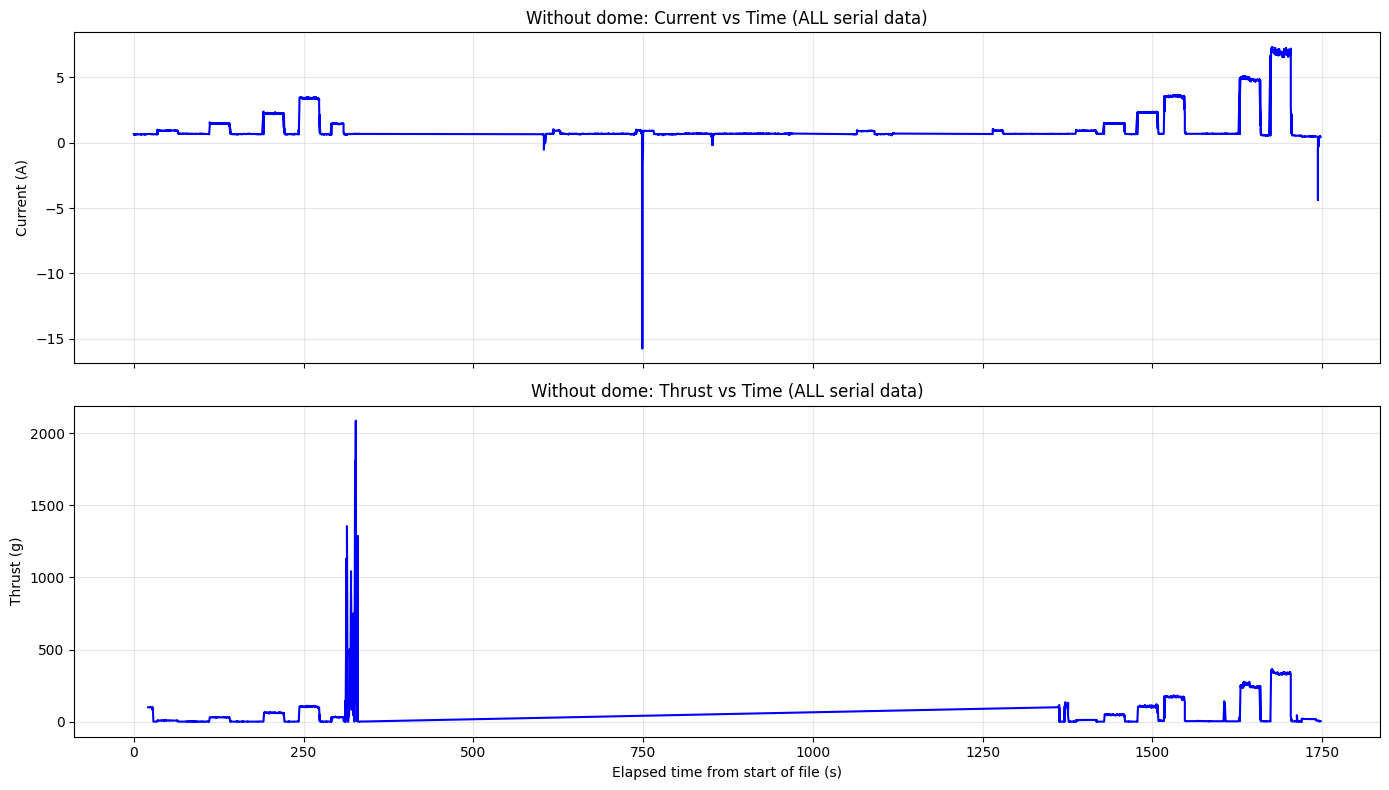

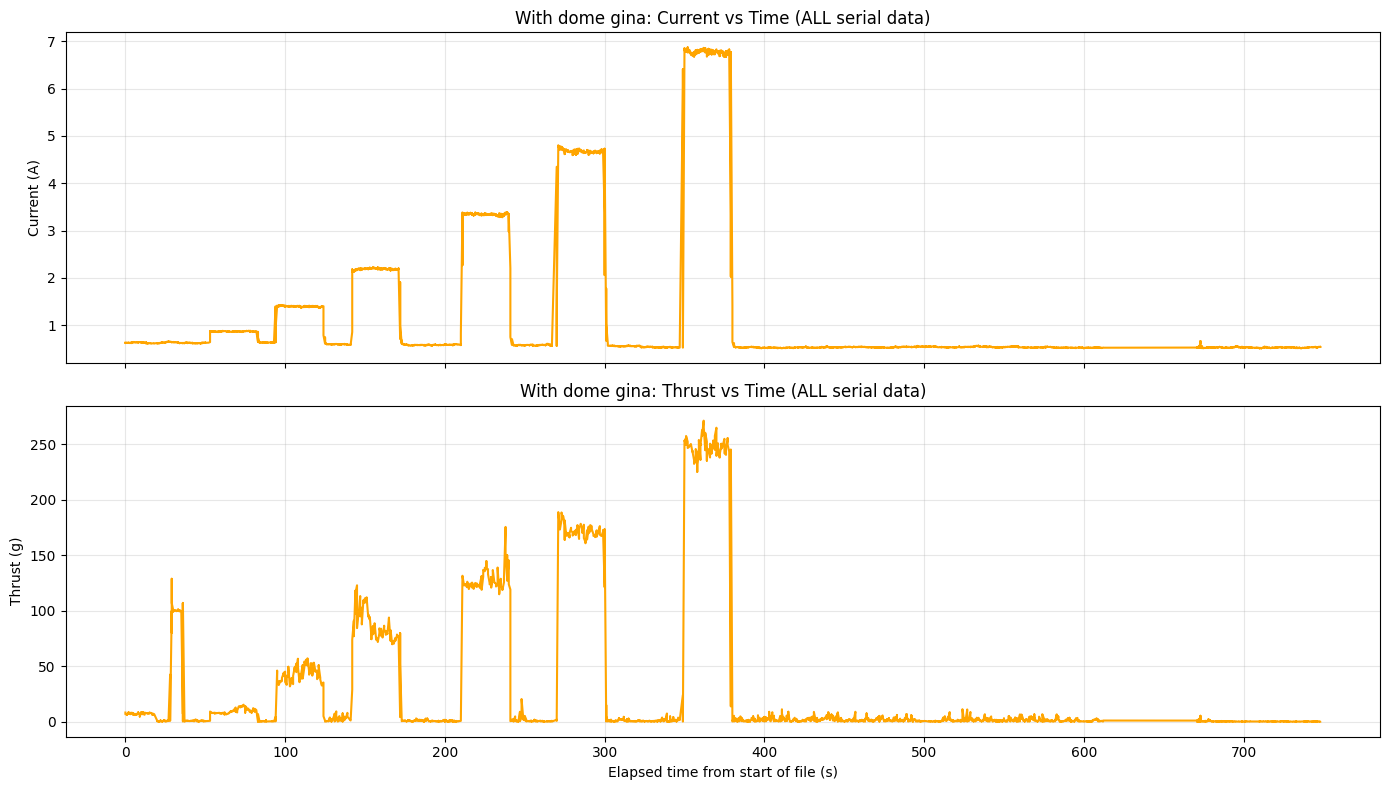

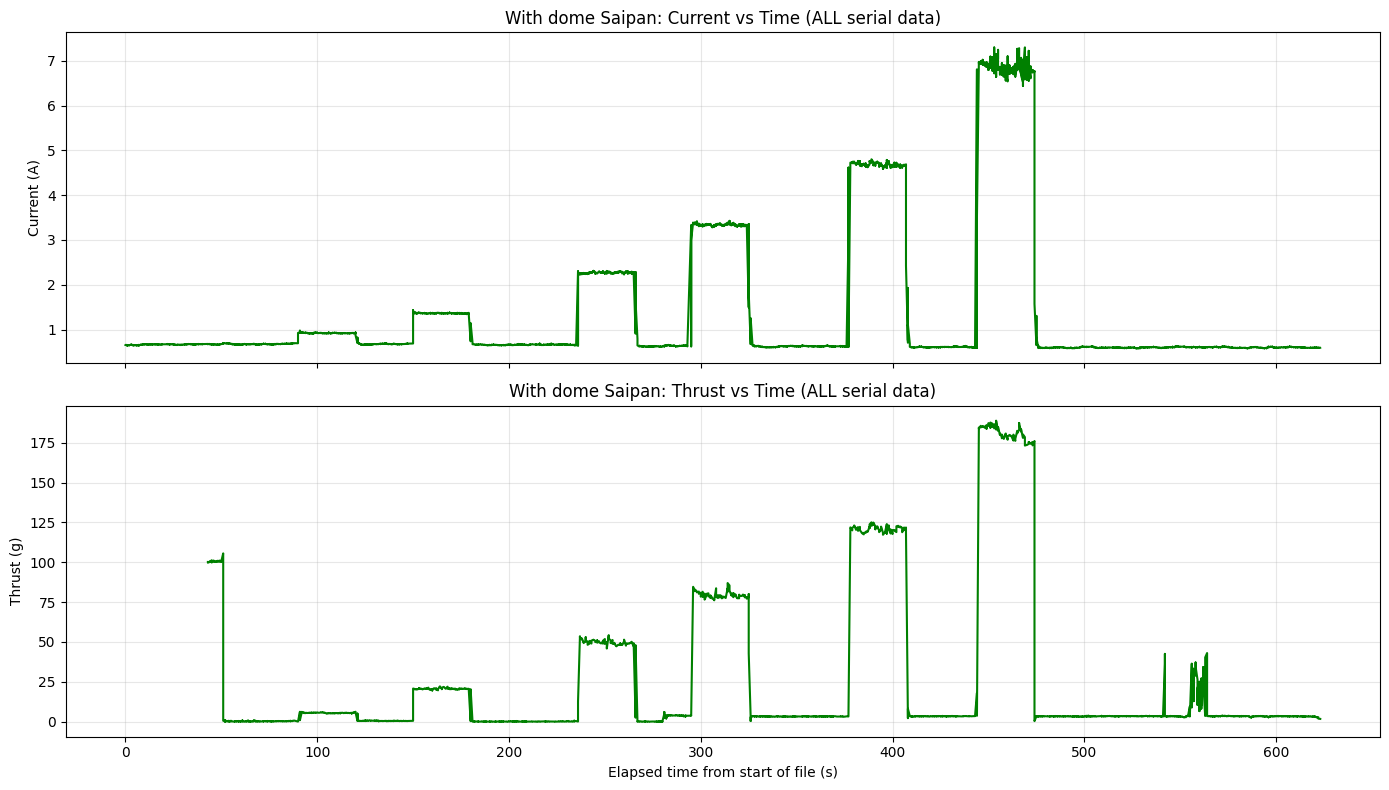

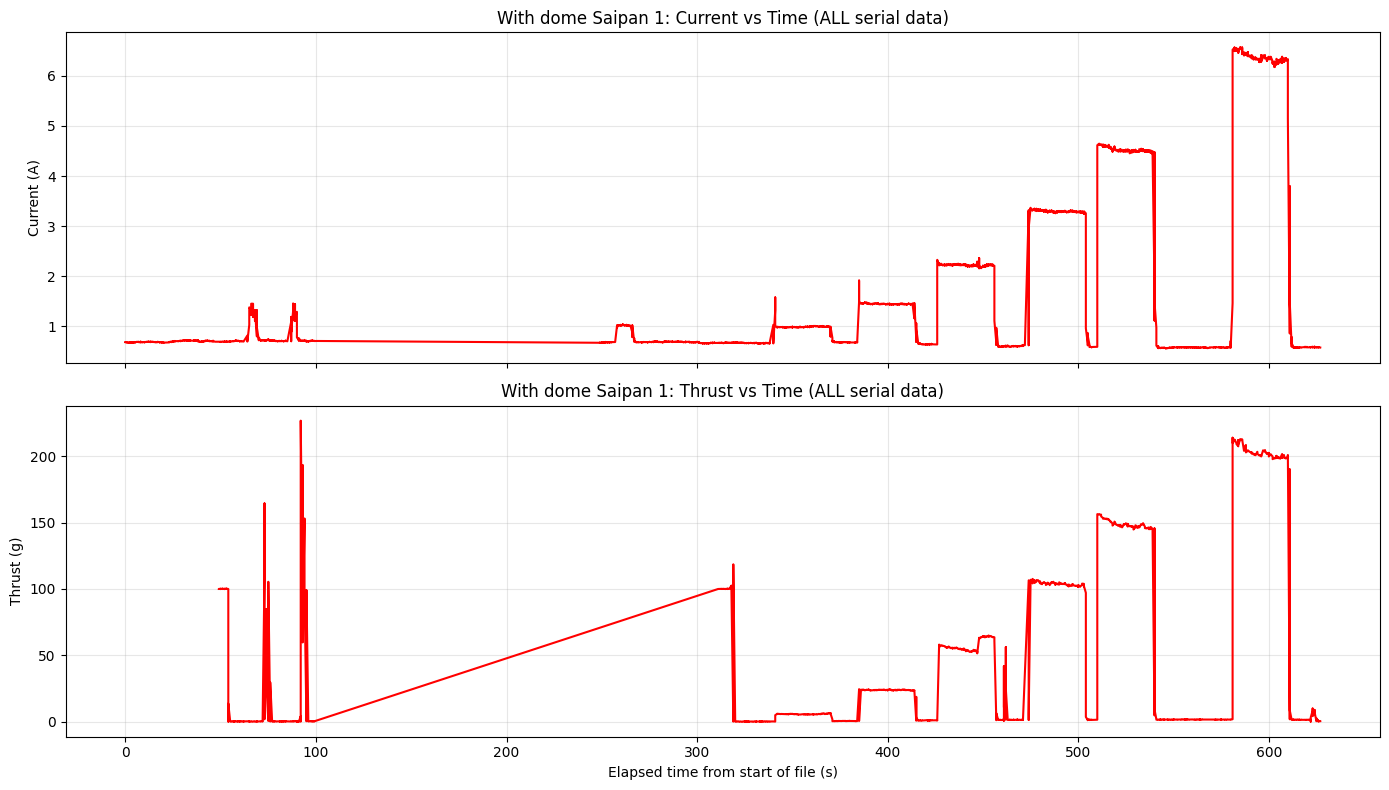

In [ ]:
def plot_all_serial_timeseries(base_dir):
    thrust_col = "thrust_abs_g" if use_absolute_thrust else "thrust_g"

    folders = [p for p in Path(base_dir).iterdir() if p.is_dir()]
    folders = sorted(folders, key=lambda p: condition_order.index(p.name) if p.name in condition_order else 999)

    for folder in folders:
        condition = folder.name
        csv_path = folder / "plot_data.csv"

        if not csv_path.exists():
            print(f"{condition}: missing plot_data.csv")
            continue

        df = parse_plot_csv(csv_path)
        if df.empty:
            print(f"{condition}: no data")
            continue

        df["elapsed_s"] = (df["pc_time"] - df["pc_time"].iloc[0]).dt.total_seconds()

        color = condition_colors.get(condition, None)

        fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

        axes[0].plot(df["elapsed_s"], df["current_a"], color=color)
        axes[0].set_title(f"{condition}: Current vs Time (ALL serial data)")
        axes[0].set_ylabel("Current (A)")
        axes[0].grid(True, alpha=0.3)

        thrust_df = df[df[thrust_col].notna()].copy()
        axes[1].plot(thrust_df["elapsed_s"], thrust_df[thrust_col], color=color)
        axes[1].set_title(f"{condition}: Thrust vs Time (ALL serial data)")
        axes[1].set_xlabel("Elapsed time from start of file (s)")
        axes[1].set_ylabel("Thrust (g)")
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


plot_all_serial_timeseries(base_dir)


In [ ]:
def plot_raw_timeseries(raw_interest, qualified_only=True, gap_s=1.0):
    thrust_col = "thrust_abs_g" if use_absolute_thrust else "thrust_g"

    for condition, df in raw_interest.items():
        if df.empty:
            continue

        work = df.copy()

        if qualified_only and "qualifies" in work.columns:
            work = work[work["qualifies"] == True].copy()

        if work.empty:
            continue

        if "control_session_id" not in work.columns:
            work = work.sort_values("pc_time").copy()
            work["control_session_id"] = 1

        session_blocks = []
        cursor_s = 0.0

        if "segment_start_ts" in work.columns:
            session_order = (
                work[["control_session_id", "segment_start_ts"]]
                .drop_duplicates()
                .sort_values(["segment_start_ts", "control_session_id"])
            )
            ordered_session_ids = session_order["control_session_id"].tolist()
        else:
            ordered_session_ids = work["control_session_id"].drop_duplicates().tolist()

        for session_id in ordered_session_ids:
            grp = work[work["control_session_id"] == session_id].sort_values("pc_time").copy()
            if grp.empty:
                continue

            start_ts = grp["segment_start_ts"].iloc[0] if "segment_start_ts" in grp.columns else grp["pc_time"].iloc[0]
            grp["plot_elapsed_s"] = (grp["pc_time"] - start_ts).dt.total_seconds() + cursor_s
            session_blocks.append(grp)

            session_duration = (grp["pc_time"].max() - start_ts).total_seconds()
            cursor_s += max(session_duration, 0) + gap_s

        if not session_blocks:
            continue

        plot_df = pd.concat(session_blocks, ignore_index=True).sort_values("plot_elapsed_s")

        fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        speed_values = sorted(plot_df["speed_pct"].dropna().unique())
        default_colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0"])
        speed_to_color = {
            speed: default_colors[i % len(default_colors)]
            for i, speed in enumerate(speed_values)
        }

        shown_labels = set()

        for session_id in ordered_session_ids:
            grp = plot_df[plot_df["control_session_id"] == session_id].copy()
            if grp.empty:
                continue

            speed = grp["speed_pct"].iloc[0] if "speed_pct" in grp.columns else np.nan
            color = speed_to_color.get(speed, None)

            label = None
            if pd.notna(speed) and speed not in shown_labels:
                label = f"{int(speed)}%"
                shown_labels.add(speed)

            axes[0].plot(grp["plot_elapsed_s"], grp["current_a"], label=label, color=color)

            thrust_part = grp[grp[thrust_col].notna()]
            axes[1].plot(thrust_part["plot_elapsed_s"], thrust_part[thrust_col], label=label, color=color)

        title_suffix = "qualified control sessions" if qualified_only else "control sessions"

        axes[0].set_title(f"{condition}: current over {title_suffix}")
        axes[0].set_ylabel("Current (A)")
        axes[0].grid(True, alpha=0.3)

        axes[1].set_title(f"{condition}: thrust over {title_suffix}")
        axes[1].set_xlabel("Elapsed time from SPEED-after-ON start, session-by-session (s)")
        axes[1].set_ylabel("Thrust (g)")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend(title="Speed")

        plt.tight_layout()
        plt.show()

plot_raw_timeseries(raw_interest, qualified_only=True, gap_s=1.0)


KeyError: 'control_session_id'

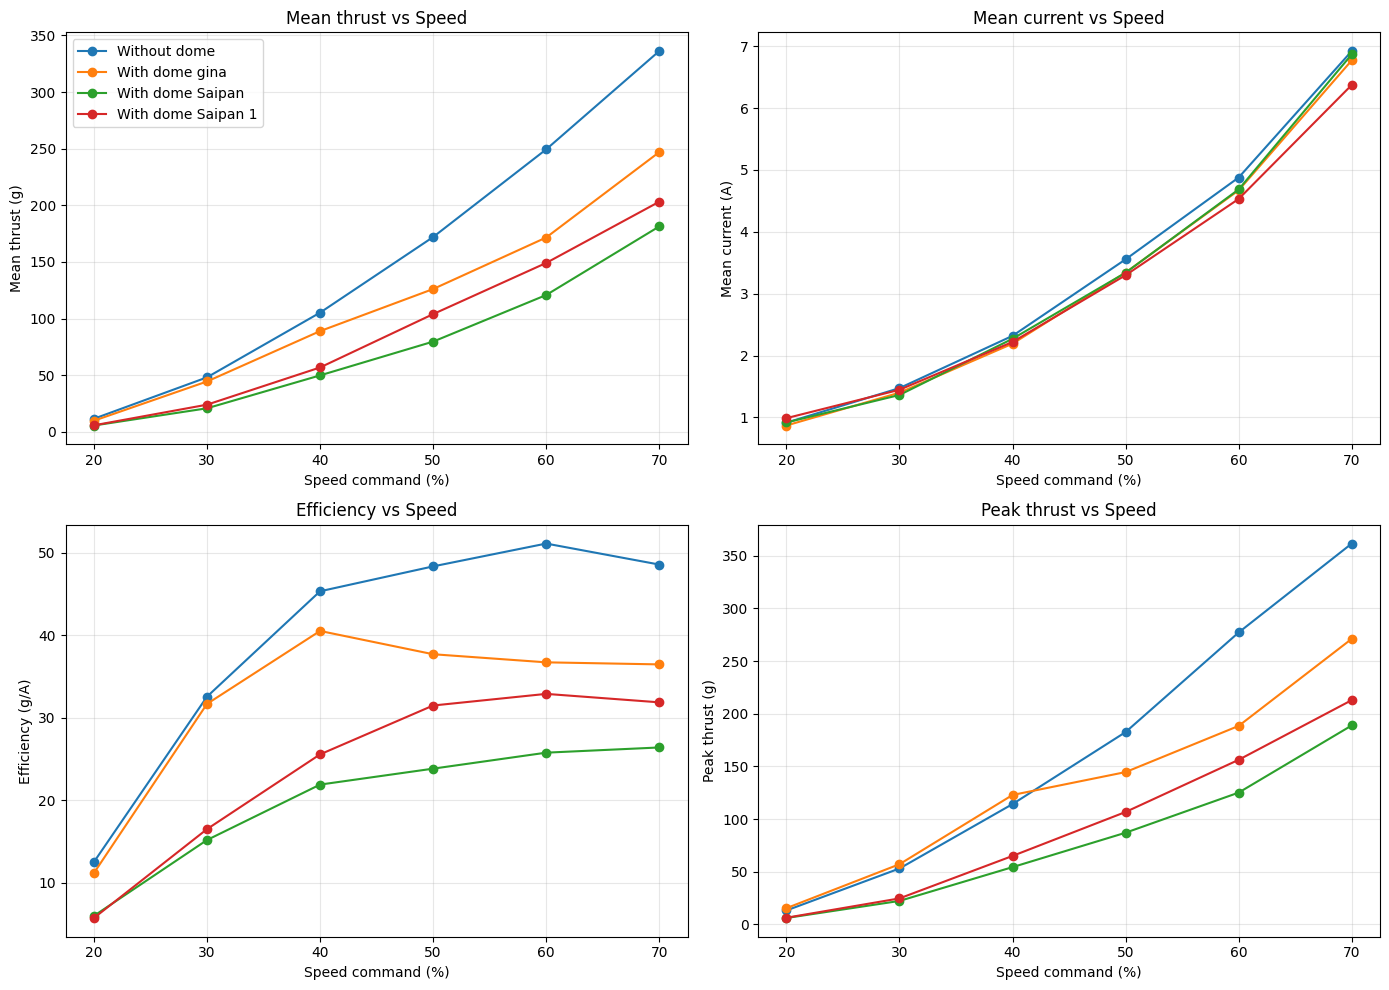

In [ ]:
def ordered_conditions(df, column="condition"):
    if df.empty or column not in df.columns:
        return []
    existing = list(df[column].dropna().unique())
    ordered = [c for c in condition_order if c in existing]
    ordered += [c for c in existing if c not in ordered]
    return ordered


def plot_compare_lines(per_speed_df):
    if per_speed_df.empty:
        print("No per-speed data available.")
        return

    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    axes = axes.ravel()

    specs = [
        ("thrust_mean_g_weighted", "Mean thrust (g)", "Mean thrust vs Speed"),
        ("current_mean_A_weighted", "Mean current (A)", "Mean current vs Speed"),
        ("power_mean_W_weighted", "Mean power (W)", "Mean power vs Speed"),
        ("efficiency_g_per_A_weighted", "Efficiency (g/A)", "Efficiency vs Speed"),
        ("efficiency_g_per_W_weighted", "Efficiency (g/W)", "Efficiency vs Speed"),
        ("thrust_peak_g_max", "Peak thrust (g)", "Peak thrust vs Speed"),
    ]

    ordered = ordered_conditions(per_speed_df)

    for ax, (col, ylabel, title) in zip(axes, specs):
        for condition in ordered:
            grp = per_speed_df[per_speed_df["condition"] == condition].sort_values("speed_pct")
            if len(grp) and col in grp.columns:
                ax.plot(grp["speed_pct"], grp[col], marker="o", label=condition)
        ax.set_xlabel("Speed command (%)")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)

    axes[0].legend()
    plt.tight_layout()
    plt.show()


plot_compare_lines(per_speed_df)


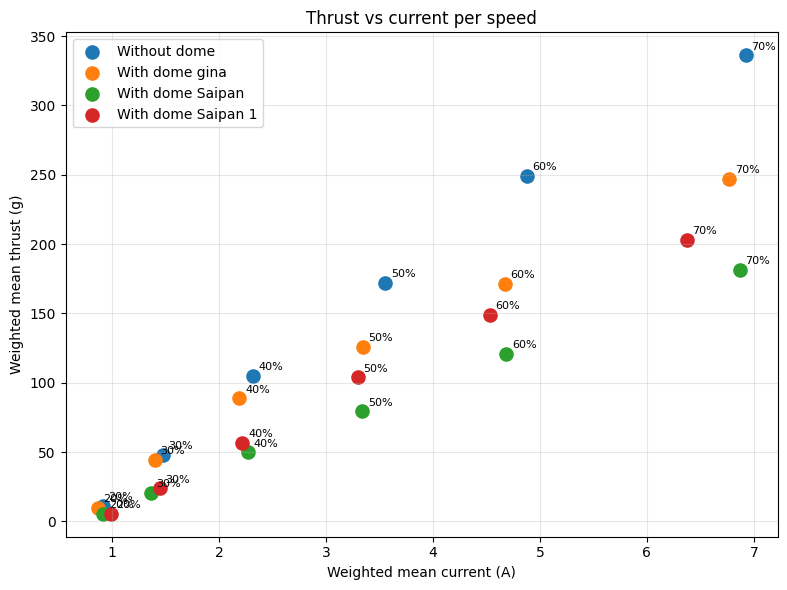

In [ ]:
def plot_scatter_thrust_vs_current(per_speed_df):
    if per_speed_df.empty:
        print("No per-speed data available.")
        return

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ordered = ordered_conditions(per_speed_df)

    for condition in ordered:
        grp = per_speed_df[per_speed_df["condition"] == condition].sort_values("speed_pct")
        if grp.empty:
            continue

        ax.scatter(grp["current_mean_A_weighted"], grp["thrust_mean_g_weighted"], s=90, label=condition)

        for _, row in grp.iterrows():
            ax.annotate(
                f'{int(row["speed_pct"])}%',
                (row["current_mean_A_weighted"], row["thrust_mean_g_weighted"]),
                textcoords="offset points",
                xytext=(4, 4),
                fontsize=8,
            )

    ax.set_title("Thrust vs current per speed")
    ax.set_xlabel("Weighted mean current (A)")
    ax.set_ylabel("Weighted mean thrust (g)")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_scatter_thrust_vs_current(per_speed_df)
